# Benchmarking the simple-archetypes method on several regions

This notebook benchmarks the **simple archetypes** soft-labeling method on
**multiple regions** at the same time, using
`sl_with_simple_archetypes_with_multiple_regions`.

Contrarily to `compare_soft_labeling_on_noisy_samples.ipynb`, which always works
within a *single* DMR, here we select an arbitrary number of regions, controlling
separately how many regions have **differentiated** cell types (one of the
selected cell types is the target of the DMR) and how many have
**non-differentiated** cell types (none of the selected cell types is the target
of the DMR).

A single set of cell types is shared across all the selected regions, and the
cell-type proportions of each (noisy) sample are shared across regions as well.
Only the archetypes of the model are estimated independently per region, while
the shared cell-type proportions are re-estimated by aggregating the expected
counts over all the regions.

In [1]:
from pathlib import Path
from collections import defaultdict
from typing import Dict, List
from time import time
from itertools import combinations

import numpy as np
import pandas as pd
import json
import pysam
from tqdm import tqdm
import matplotlib.pyplot as plt

from utils import (
    filename2ctype,
    nrmse,
    compute_counts_sig_per_ctype_from_dataset,
    extract_complete_dataset,
    compute_num_reads_in_dataset,
    generate_bootstrap_sample_from_dataset,
    compute_nrmse_per_sig_length,
)
from methods import (
    naive_sl_without_pooling,
    sl_with_simple_archetypes_with_multiple_regions,
)

%load_ext autoreload
%autoreload 2

## Data preparation

### Configuration



We choose a single set of `N_CTYPES` cell types that is shared across all the
selected regions, and we control how many **differentiated** and
**non-differentiated** regions we want to include.

In [2]:
# Number of cell types shared across all the selected regions.
N_CTYPES = 2

# Number of regions of each kind to select.
N_DIFFERENTIATED_REGIONS = 2  # at least one selected ctype is the target of the DMR
N_NON_DIFFERENTIATED_REGIONS = 8  # none of the selected ctypes is the target of the DMR
N_REGIONS = N_DIFFERENTIATED_REGIONS + N_NON_DIFFERENTIATED_REGIONS

# Size of the pool of high-coverage candidate cell types from which the N_CTYPES
# shared cell types are chosen (keeps the joint selection tractable).
CANDIDATE_CTYPE_POOL_SIZE = 12

# Cap on the number of signature start positions kept per region (controls the
# CpG span, hence the size of the archetypes and the runtime).
LIMIT_NUMBER_START_POSITIONS_PER_REGION = 10

# Cap on the signature read length (bounds the number of signatures 2**L).
MAX_SIGNATURE_READ_LENGTH = 8

assert N_REGIONS >= 1
assert CANDIDATE_CTYPE_POOL_SIZE >= N_CTYPES

### Loading the coverage, atlas and labels



First we load the file containing the coverage per ctype per DMR, add the DMR
target column from the atlas, and load the cell-type labels.

In [3]:
df_coverage_per_ctype_per_dmr = pd.read_csv(Path("./data/region_coverage.csv"))
df_coverage_per_ctype_per_dmr.columns = [
    col if col != "Ovary+Endom-Ep" else "Ovary-Ep"
    for col in df_coverage_per_ctype_per_dmr.columns
]
atlas = pd.read_csv(Path("../../Data/Atlas.U25.l4.hg38.full.tsv"), sep="\t")
# add target column to df_coverage_per_ctype_per_dmr
map_region_key_to_target = atlas.set_index(["chr", "start", "end"])["target"].to_dict()
df_coverage_per_ctype_per_dmr["target"] = df_coverage_per_ctype_per_dmr.apply(
    lambda row: map_region_key_to_target.get((row["chr"], row["start"], row["end"])),
    axis=1,
)

labels_dict = json.load(open(Path("../../App/labels_dict.json"), "r", encoding="utf-8"))
labels_dict = {int(k): v for k, v in labels_dict.items()}
labels_list = [labels_dict[i] for i in range(len(labels_dict))]

### Joint selection of the cell types and regions



We select a single set of `N_CTYPES` cell types (shared across all regions) and a
set of regions such that:

- exactly `N_DIFFERENTIATED_REGIONS` regions have their DMR target **among** the
  selected cell types, with each differentiated region having a **distinct**
  target cell type, and
- exactly `N_NON_DIFFERENTIATED_REGIONS` regions have their DMR target **outside**
  the selected cell types,

while maximizing the worst-case coverage (the minimum, over all selected regions
and selected cell types, of the per-cell-type coverage at the region). The
candidate cell types are restricted to the `CANDIDATE_CTYPE_POOL_SIZE` cell types
with the highest median coverage to keep the combinatorial search tractable.


In [4]:
# Keep only DMRs whose target is one of the known cell types.
df_valid_regions = df_coverage_per_ctype_per_dmr[
    df_coverage_per_ctype_per_dmr["target"].isin(labels_list)
].reset_index(drop=True)

coverage_matrix = df_valid_regions[labels_list].values.astype(
    float
)  # (n_regions, n_all_ctypes)
target_ctype_idx_per_region = np.array(
    [labels_list.index(t) for t in df_valid_regions["target"]]
)

# Restrict the candidate cell types to the highest-median-coverage ones.
median_coverage_per_ctype = np.median(coverage_matrix, axis=0)
candidate_ctype_indices = np.argsort(median_coverage_per_ctype)[::-1][
    :CANDIDATE_CTYPE_POOL_SIZE
]

best_score = -1.0
best_ctype_indices = None
best_diff_region_rows = None
best_non_diff_region_rows = None

for ctype_combo in combinations(sorted(candidate_ctype_indices.tolist()), N_CTYPES):
    ctype_combo = list(ctype_combo)
    ctype_combo_set = set(ctype_combo)

    # Worst-case (minimum) coverage over the selected cell types, per region.
    min_coverage_per_region = coverage_matrix[:, ctype_combo].min(axis=1)

    target_in_combo = np.array(
        [t in ctype_combo_set for t in target_ctype_idx_per_region]
    )
    diff_region_rows = np.where(target_in_combo)[0]
    non_diff_region_rows = np.where(~target_in_combo)[0]

    # Among the differentiated regions, keep at most one region per target cell
    # type (the highest-coverage one) so that the selected differentiated
    # regions all have distinct target cell types.
    diff_region_rows = diff_region_rows[
        np.argsort(min_coverage_per_region[diff_region_rows])[::-1]
    ]
    seen_diff_targets = set()
    unique_target_diff_rows = []
    for r in diff_region_rows:
        t = target_ctype_idx_per_region[r]
        if t in seen_diff_targets:
            continue
        seen_diff_targets.add(t)
        unique_target_diff_rows.append(r)
    diff_region_rows = np.array(unique_target_diff_rows, dtype=int)

    if (
        len(diff_region_rows) < N_DIFFERENTIATED_REGIONS
        or len(non_diff_region_rows) < N_NON_DIFFERENTIATED_REGIONS
    ):
        continue

    # Greedily keep the highest-coverage regions of each kind. The differentiated
    # rows are already sorted by coverage and have distinct target cell types.
    diff_region_rows = diff_region_rows[:N_DIFFERENTIATED_REGIONS]
    non_diff_region_rows = non_diff_region_rows[
        np.argsort(min_coverage_per_region[non_diff_region_rows])[::-1]
    ][:N_NON_DIFFERENTIATED_REGIONS]

    selected_region_rows = np.concatenate(
        [diff_region_rows, non_diff_region_rows]
    ).astype(int)
    score = min_coverage_per_region[selected_region_rows].min()
    if score > best_score:
        best_score = score
        best_ctype_indices = ctype_combo
        best_diff_region_rows = diff_region_rows
        best_non_diff_region_rows = non_diff_region_rows

assert best_ctype_indices is not None, (
    "No feasible (cell types, regions) selection found. Try increasing "
    "CANDIDATE_CTYPE_POOL_SIZE or reducing the number of requested regions."
)

selected_ctypes = [labels_list[i] for i in best_ctype_indices]
print(f"Selected cell types: {selected_ctypes}")
print(f"Worst-case coverage of the selection: {best_score}")

Selected cell types: ['Blood-T', 'Head-Neck-Ep']
Worst-case coverage of the selection: 2868.0


In [5]:
# Build the list of selected regions (differentiated ones first).
selected_region_rows = list(best_diff_region_rows) + list(best_non_diff_region_rows)
selected_regions = []
for region_id, row_idx in enumerate(selected_region_rows):
    row = df_valid_regions.iloc[int(row_idx)]
    is_differentiated = region_id < N_DIFFERENTIATED_REGIONS
    selected_regions.append(
        {
            "region_id": region_id,
            "chr": row["chr"],
            "start": int(row["start"]),
            "end": int(row["end"]),
            "startCpG": int(row["startCpG"]),
            "endCpG": int(row["endCpG"]),
            "fetch_start": int(row["startCpG"]) - 50,
            "target": row["target"],
            "setting": "differentiated" if is_differentiated else "non_differentiated",
        }
    )

pd.DataFrame(selected_regions)[
    ["region_id", "setting", "chr", "startCpG", "endCpG", "target"]
]

,region_id,setting,chr,startCpG,endCpG,target
0,0,differentiated,chr11,17571299,17571310,Blood-T
1,1,differentiated,chr10,15939120,15939132,Head-Neck-Ep
2,2,non_differentiated,chr22,27661520,27661554,Gallbladder
3,3,non_differentiated,chr2,3380908,3380917,Pancreas-Duct
4,4,non_differentiated,chr11,17582874,17582891,Pancreas-Acinar
5,5,non_differentiated,chr5,8890345,8890361,Eryth-prog
6,6,non_differentiated,chr2,3176527,3176539,Lung-Ep-Alveo
7,7,non_differentiated,chr2,2657207,2657225,Small-Int-Ep
8,8,non_differentiated,chr2,3614411,3614428,Thyroid-Ep
9,9,non_differentiated,chr6,10044475,10044486,Lung-Ep-Alveo


### Extraction of reads



For every selected region, reads are organized in a nested dictionary keyed first
by region, then by cell type, then by the number of CpG sites in the reads, and
finally by the individual starting positions. The values are dictionaries mapping
the methylation pattern to the number of reads with that pattern:

```
raw_reads_dataset[region_id][ctype][read_length][start][pattern] = count
```

We first extract the raw reads (so the pattern may contain unknown values `.`),
then split the reads at the unknown positions, and finally build a "complete"
dataset where each read of size n also contributes all of its sub-reads of size
> n (to be used position per position only).

In [6]:
# Get the list of file paths per ctype (shared across all regions).
PATH_TO_DATA = Path(
    "/staging/leuven/stg_00118/methylDL/data/loyfer2023/hg38/data/GSE186458"
)
files_per_ctype = defaultdict(list)
for file in PATH_TO_DATA.glob("*.pat.gz"):
    ctype = filename2ctype(file.name)
    if ctype in selected_ctypes:
        files_per_ctype[ctype].append(file)
files_per_ctype = dict(files_per_ctype)
{ctype: len(files) for ctype, files in files_per_ctype.items()}

{'Blood-T': 22, 'Head-Neck-Ep': 13}

In [7]:
# Extract the raw reads dataset for every selected region and ctype.
raw_reads_dataset = {
    region["region_id"]: defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for region in selected_regions
}

n_loops = sum(len(files) for files in files_per_ctype.values())
with tqdm(total=n_loops, desc="Extracting reads") as pbar:
    for ctype, files in files_per_ctype.items():
        for file in files:
            csi_file_path = str(file) + ".csi"
            tbx = pysam.TabixFile(str(file), index=csi_file_path)
            for region in selected_regions:
                region_id = region["region_id"]
                dmr_start_cpg = region["startCpG"]
                dmr_end_cpg = region["endCpG"]
                for row in tbx.fetch(
                    region["chr"], region["fetch_start"], dmr_end_cpg + 1
                ):
                    parts = row.split("\t")
                    read_start = int(parts[1])
                    pattern = parts[2]
                    n_reads = int(parts[3])
                    read_end = read_start + len(pattern)  # exclusive
                    # crop the read to the dmr region
                    if read_end < dmr_start_cpg:
                        continue  # the read ends before the dmr start
                    if read_start >= dmr_end_cpg:
                        continue  # the read starts after the dmr end
                    cropped_pattern_start = max(read_start, dmr_start_cpg)
                    cropped_pattern_end = min(read_end, dmr_end_cpg)
                    cropped_pattern = pattern[
                        cropped_pattern_start
                        - read_start : cropped_pattern_end
                        - read_start
                    ]
                    if len(cropped_pattern) == 0:
                        continue  # the read does not overlap with the dmr
                    cropped_pattern = cropped_pattern.replace("C", "1").replace(
                        "T", "0"
                    )
                    raw_reads_dataset[region_id][ctype][len(cropped_pattern)][
                        cropped_pattern_start
                    ][cropped_pattern] += n_reads
            pbar.update(1)

for region in selected_regions:
    region_id = region["region_id"]
    print(
        f"Region {region_id} ({region['setting']}, target={region['target']}): "
        f"{compute_num_reads_in_dataset(raw_reads_dataset[region_id])} raw reads"
    )

Extracting reads: 100%|██████████| 35/35 [00:00<00:00, 57.06it/s]

Region 0 (differentiated, target=Blood-T): 8556 raw reads
Region 1 (differentiated, target=Head-Neck-Ep): 7301 raw reads
Region 2 (non_differentiated, target=Gallbladder): 10202 raw reads
Region 3 (non_differentiated, target=Pancreas-Duct): 8651 raw reads
Region 4 (non_differentiated, target=Pancreas-Acinar): 8081 raw reads
Region 5 (non_differentiated, target=Eryth-prog): 7898 raw reads
Region 6 (non_differentiated, target=Lung-Ep-Alveo): 7818 raw reads
Region 7 (non_differentiated, target=Small-Int-Ep): 7658 raw reads
Region 8 (non_differentiated, target=Thyroid-Ep): 7311 raw reads
Region 9 (non_differentiated, target=Lung-Ep-Alveo): 7911 raw reads


In [8]:
# Optionally cap the number of signature start positions per region to keep the
# CpG span (and thus the archetypes and the runtime) manageable.
if LIMIT_NUMBER_START_POSITIONS_PER_REGION is not None:
    for region in selected_regions:
        region_id = region["region_id"]
        all_start_positions = set()
        for ctype, length_dict in raw_reads_dataset[region_id].items():
            for length, start_dict in length_dict.items():
                all_start_positions.update(start_dict.keys())
        authorized_start_positions = set(
            sorted(all_start_positions)[:LIMIT_NUMBER_START_POSITIONS_PER_REGION]
        )
        for ctype, length_dict in raw_reads_dataset[region_id].items():
            for length, start_dict in length_dict.items():
                for start in list(start_dict.keys()):
                    if start not in authorized_start_positions:
                        del start_dict[start]

In [9]:
# Build the original reads dataset by splitting the patterns at the unknown
# positions "." (per region).
og_dataset = {}
for region in selected_regions:
    region_id = region["region_id"]
    region_og = defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for ctype, length_dict in raw_reads_dataset[region_id].items():
        for read_length in sorted(length_dict.keys()):  # start from the shortest reads
            for start, pattern_counts in length_dict[read_length].items():
                for pattern, n_reads in pattern_counts.items():
                    subpatterns = pattern.split(".")
                    current_pos = start
                    for subpattern in subpatterns:
                        subpattern_start = current_pos
                        current_pos += len(subpattern)
                        if len(subpattern) == 0:
                            continue  # skip empty subpatterns
                        region_og[ctype][len(subpattern)][subpattern_start][
                            subpattern
                        ] += n_reads
    og_dataset[region_id] = region_og

for region in selected_regions:
    region_id = region["region_id"]
    print(
        f"Region {region_id}: "
        f"{compute_num_reads_in_dataset(og_dataset[region_id])} reads after splitting "
        f"at unknown positions"
    )

Region 0: 8120 reads after splitting at unknown positions
Region 1: 5951 reads after splitting at unknown positions
Region 2: 4590 reads after splitting at unknown positions
Region 3: 8676 reads after splitting at unknown positions
Region 4: 6885 reads after splitting at unknown positions
Region 5: 3995 reads after splitting at unknown positions
Region 6: 7781 reads after splitting at unknown positions
Region 7: 5542 reads after splitting at unknown positions
Region 8: 4791 reads after splitting at unknown positions
Region 9: 7574 reads after splitting at unknown positions


In [10]:
# Build the complete dataset (per region) by splitting long patterns into all
# possible subpatterns.
complete_og_dataset = {
    region["region_id"]: extract_complete_dataset(og_dataset[region["region_id"]])
    for region in selected_regions
}
for region in selected_regions:
    region_id = region["region_id"]
    print(
        f"Region {region_id}: "
        f"{compute_num_reads_in_dataset(complete_og_dataset[region_id])} reads in the "
        f"complete dataset"
    )

Region 0: 26258 reads in the complete dataset
Region 1: 34064 reads in the complete dataset
Region 2: 41758 reads in the complete dataset
Region 3: 17485 reads in the complete dataset
Region 4: 41916 reads in the complete dataset
Region 5: 56123 reads in the complete dataset
Region 6: 21473 reads in the complete dataset
Region 7: 61535 reads in the complete dataset
Region 8: 24109 reads in the complete dataset
Region 9: 30602 reads in the complete dataset


For each region we create the dict of all pairs (pattern start, pattern length)
(over all ctypes), which represent the possible positions of signatures.

In [11]:
# For each region, identify the (start, read_length) signature positions common
# to all ctypes (and within the read-length cap).
signature_positions = {}
for region in selected_regions:
    region_id = region["region_id"]

    start_positions_per_ctype = defaultdict(set)
    for ctype, length_dict in complete_og_dataset[region_id].items():
        for read_length, start_dict in length_dict.items():
            for start in start_dict.keys():
                start_positions_per_ctype[ctype].add(start)
    common_start_positions = set.intersection(*start_positions_per_ctype.values())

    signature_positions_per_ctype = defaultdict(lambda: defaultdict(set))
    for ctype, length_dict in complete_og_dataset[region_id].items():
        for read_length, start_dict in length_dict.items():
            if read_length > MAX_SIGNATURE_READ_LENGTH:
                continue
            for start in start_dict.keys():
                if start not in common_start_positions:
                    continue
                signature_positions_per_ctype[ctype][start].add(read_length)

    region_signature_positions = {}
    for start in common_start_positions:
        common_read_lengths = set.intersection(
            *[signature_positions_per_ctype[ctype][start] for ctype in selected_ctypes]
        )
        if len(common_read_lengths) > 0:
            region_signature_positions[start] = common_read_lengths
    signature_positions[region_id] = region_signature_positions

for region in selected_regions:
    region_id = region["region_id"]
    assert (
        len(signature_positions[region_id]) > 0
    ), f"Region {region_id} has no common signature positions across ctypes."
    n_sigs = sum(len(v) for v in signature_positions[region_id].values())
    print(f"Region {region_id}: {n_sigs} (start, read_length) signature positions")

Region 0: 34 (start, read_length) signature positions
Region 1: 55 (start, read_length) signature positions
Region 2: 128 (start, read_length) signature positions
Region 3: 23 (start, read_length) signature positions
Region 4: 85 (start, read_length) signature positions
Region 5: 68 (start, read_length) signature positions
Region 6: 41 (start, read_length) signature positions
Region 7: 94 (start, read_length) signature positions
Region 8: 59 (start, read_length) signature positions
Region 9: 40 (start, read_length) signature positions


## Ground truth $P(\mathrm{sig}\mid\mathrm{ctype})$ per region



As in `compare_soft_labeling_on_noisy_samples.ipynb`, we construct the pseudo
ground truth (PGT) for $P(\mathrm{signature}\mid\mathrm{ctype})$ for each region by
counting on the complete dataset (no pooling between signatures) and normalizing
per cell type with the naive soft labels without pooling.

In [12]:
complete_og_counts_sig_per_ctype = {}
og_counts_sig_per_ctype = {}
pgt_naive_sl_sig_given_ctype = {}
for region in selected_regions:
    region_id = region["region_id"]
    complete_og_counts_sig_per_ctype[region_id] = (
        compute_counts_sig_per_ctype_from_dataset(
            complete_og_dataset[region_id],
            signature_positions[region_id],
            selected_ctypes,
            N_CTYPES,
        )
    )  # with the complete dataset
    og_counts_sig_per_ctype[region_id] = compute_counts_sig_per_ctype_from_dataset(
        og_dataset[region_id],
        signature_positions[region_id],
        selected_ctypes,
        N_CTYPES,
    )  # with the reads dataset
    # naive soft labels without pooling (warning expected for zero-count signatures)
    pgt_naive_sl_sig_given_ctype[region_id] = naive_sl_without_pooling(
        complete_og_counts_sig_per_ctype[region_id]
    )

## Construction of noisy samples and helper functions



A **noisy sample** is a mixture of the selected cell types: a fraction $p_{b,c}$
of its reads is drawn from the pure read distribution of cell type $c$. The mixing
proportions $p_{b,c}$ are **shared across all the regions** (the same samples are
observed in every region).

In [13]:
def build_ctype_prop_per_sample(
    base_noise_level: float,
    std_noise_on_noise: float,
    n_samples: int,
    n_ctypes: int = N_CTYPES,
    dominant_ctype_fixed: int = None,
) -> np.ndarray:
    """Build per-sample mixing proportions (shared across all regions).

    Samples cycle through the dominant cell type. The dominant cell type gets
    proportion ``1 - base_noise_level`` and the remaining ``base_noise_level`` is
    spread equally over the other cell types.
    """
    props = np.zeros((n_samples, n_ctypes))
    for b in range(n_samples):
        if dominant_ctype_fixed is not None:
            dominant = dominant_ctype_fixed
        else:
            dominant = b % n_ctypes
        props[b, dominant] = (
            1.0 - base_noise_level + np.random.normal(0, std_noise_on_noise)
        )
        others = [c for c in range(n_ctypes) if c != dominant]
        for c in others:
            props[b, c] = base_noise_level / len(others) + np.random.normal(
                0, std_noise_on_noise
            )
    props = np.clip(props, 1e-6, None)
    props = props / props.sum(axis=1, keepdims=True)  # normalize to sum to 1
    return props


def generate_noisy_samples_counts_single_region(
    source_dataset,
    selected_ctypes_,
    ctype_prop_per_sample: np.ndarray,
    sample_sizes: np.ndarray,
    sig_positions,
    n_ctypes: int,
):
    """Per-sample signature counts for noisy (mixed) samples in a single region.

    For each sample b and each cell type c, ``round(p_{b,c} * sample_size_b)``
    reads are drawn (with replacement) from the pure read distribution of c in the
    region, and the resulting signature counts are summed across cell types.

    Returns ``{start: {read_length: np.ndarray of shape (n_samples, 2**read_length)}}``.
    """
    n_samples = ctype_prop_per_sample.shape[0]
    counts_sig_per_sample = {
        start: {
            read_length: np.zeros((n_samples, 2**read_length), dtype=int)
            for read_length in read_lengths
        }
        for start, read_lengths in sig_positions.items()
    }
    for b in range(n_samples):
        for c_idx, ctype in enumerate(selected_ctypes_):
            n_reads_c = int(round(ctype_prop_per_sample[b, c_idx] * sample_sizes[b]))
            if n_reads_c <= 0:
                continue
            single_ctype_dataset = {ctype: source_dataset[ctype]}
            sampled = generate_bootstrap_sample_from_dataset(
                single_ctype_dataset, dataset_size_to_sample=n_reads_c
            )
            sampled_counts = compute_counts_sig_per_ctype_from_dataset(
                sampled, sig_positions, [ctype], 1
            )
            for start, read_lengths in sampled_counts.items():
                for read_length, counts in read_lengths.items():
                    counts_sig_per_sample[start][read_length][b] += counts[0]
    return counts_sig_per_sample


def generate_noisy_samples_counts_multi_region(
    source_dataset_per_region,
    selected_ctypes_,
    ctype_prop_per_sample: np.ndarray,
    sample_sizes: np.ndarray,
    sig_positions_per_region,
    n_ctypes: int,
):
    """Per-sample signature counts for noisy samples across several regions.

    The same samples (hence the same ``ctype_prop_per_sample``) are used in every
    region; for each region the reads are drawn from that region's pure read
    distributions.

    Returns ``{region_id: {start: {read_length: np.ndarray (n_samples, 2**read_length)}}}``.
    """
    return {
        region_id: generate_noisy_samples_counts_single_region(
            source_dataset_per_region[region_id],
            selected_ctypes_,
            ctype_prop_per_sample,
            sample_sizes,
            sig_positions_per_region[region_id],
            n_ctypes,
        )
        for region_id in source_dataset_per_region
    }


def perturb_proportions(true_props: np.ndarray, noise_std: float, rng) -> np.ndarray:
    """Return a noisy estimate of the proportions (clipped and renormalized)."""
    noisy = true_props + rng.normal(0.0, noise_std, size=true_props.shape)
    noisy = np.clip(noisy, 1e-3, None)
    noisy = noisy / noisy.sum(axis=1, keepdims=True)
    return noisy


def compute_nrmse_per_sig_length_multi_region(
    predicted_per_region,
    true_per_region,
    counts_sig_per_ctype_per_region,
    min_count_threshold_per_ctype,
):
    """Pool the per-region NRMSE of P(sig | ctype), per signature length.

    The per-region averages are pooled with a weight equal to the number of
    (signature, ctype) pairs considered, which yields the exact pooled mean.
    """
    weighted_sum_per_length = defaultdict(float)
    total_count_per_length = defaultdict(int)
    for region_id in predicted_per_region:
        avg_per_length, count_per_length = compute_nrmse_per_sig_length(
            predicted_per_region[region_id],
            true_per_region[region_id],
            counts_sig_per_ctype=counts_sig_per_ctype_per_region[region_id],
            min_count_threshold_per_ctype=min_count_threshold_per_ctype,
        )
        for read_length, avg_value in avg_per_length.items():
            count = count_per_length[read_length]
            weighted_sum_per_length[read_length] += avg_value * count
            total_count_per_length[read_length] += count
    return {
        read_length: weighted_sum_per_length[read_length]
        / total_count_per_length[read_length]
        for read_length in weighted_sum_per_length
        if total_count_per_length[read_length] > 0
    }

## Experiment 1: deconvolution with oracle proportions



We construct noisy samples and deconvolve them with the simple-archetypes method
across all the regions jointly, providing the **oracle** mixing proportions (the
method does not re-estimate them). We plot the distribution of the NRMSE between
the estimated $P(\mathrm{sig}\mid\mathrm{ctype})$ and the ground-truth
$P(\mathrm{sig}\mid\mathrm{ctype})$ (pooled over all regions), per pattern length,
as a function of the contamination fraction.

In [ ]:
N_SIMULATIONS = 20
N_NOISY_SAMPLES = 10  # number of noisy samples jointly deconvolved per simulation
SAMPLE_SIZE = 200  # number of reads per noisy sample per region
MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE = 5
MAX_NUM_ITERATIONS = 500  # max number of iterations for the EM algorithm
DELTA_TOL = 1e-5  # convergence threshold for the EM algorithm
noise_grid = np.array([0.0, 0.1, 0.25, 0.5])
std_noise_on_noise = 0.1  # standard deviation of the noise added to the noise level
min_count_threshold_per_ctype_for_nrmse = 5

In [ ]:
# Reference counts used to decide which (sig, ctype) pairs are considered in the
# NRMSE (those with ground-truth support). Kept fixed across simulations.
ref_counts_for_nrmse = og_counts_sig_per_ctype

# Store raw predictions per noise level.
results_exp1_predictions = {noise_level: [] for noise_level in noise_grid}

n_loops = len(noise_grid) * N_SIMULATIONS
with tqdm(total=n_loops, desc="Exp 1: oracle proportions") as pbar:
    for noise_level in noise_grid:
        for sim_id in range(N_SIMULATIONS):
            ctype_prop_per_sample = build_ctype_prop_per_sample(
                noise_level, std_noise_on_noise, N_NOISY_SAMPLES, N_CTYPES
            )
            sample_sizes = np.full(N_NOISY_SAMPLES, SAMPLE_SIZE, dtype=int)
            counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
                og_dataset,
                selected_ctypes,
                ctype_prop_per_sample,
                sample_sizes,
                signature_positions,
                N_CTYPES,
            )

            # the method receives the oracle proportions and does not re-estimate them
            simple_archetypes_sig_given_ctype = (
                sl_with_simple_archetypes_with_multiple_regions(
                    counts_sig_per_sample,
                    ctype_prop_per_sample,
                    reestimate_ctype_proba_per_sample=False,
                    max_num_iterations=MAX_NUM_ITERATIONS,
                    delta_tol=DELTA_TOL,
                )
            )
            results_exp1_predictions[noise_level].append(
                simple_archetypes_sig_given_ctype
            )
            pbar.update(1)

In [ ]:
# Compute the pooled NRMSE from the stored predictions.
results_exp1_per_noise_per_read_length = {
    noise_level: {
        read_length: []
        for read_length in range(1, MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE + 1)
    }
    for noise_level in noise_grid
}

for noise_level in noise_grid:
    for predicted_sig_given_ctype in results_exp1_predictions[noise_level]:
        nrmse_per_length = compute_nrmse_per_sig_length_multi_region(
            predicted_sig_given_ctype,
            pgt_naive_sl_sig_given_ctype,
            ref_counts_for_nrmse,
            min_count_threshold_per_ctype_for_nrmse,
        )
        for read_length in range(1, MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE + 1):
            if read_length in nrmse_per_length:
                results_exp1_per_noise_per_read_length[noise_level][read_length].append(
                    nrmse_per_length[read_length]
                )

In [ ]:
fig, axes = plt.subplots(
    MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE,
    1,
    figsize=(1.6 * len(noise_grid) + 2, 4 * MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE),
    sharex=True,
    squeeze=False,
)
for row_idx, read_length in enumerate(
    range(1, MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE + 1)
):
    ax = axes[row_idx, 0]
    data_to_plot = [
        results_exp1_per_noise_per_read_length[noise_level][read_length]
        for noise_level in noise_grid
    ]
    bp = ax.boxplot(
        data_to_plot,
        positions=range(len(noise_grid)),
        patch_artist=True,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("tab:red")
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_ylim(0, None)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylabel(f"Read length={read_length}\nNRMSE")
    ax.set_xticks(range(len(noise_grid)))
    ax.set_xticklabels([f"{noise_level:.2f}" for noise_level in noise_grid])
axes[-1, 0].set_xlabel("Base contamination")

fig.suptitle(
    "Simple archetypes (oracle proportions): NRMSE of estimated P(signature | ctype) "
    "vs sample noise level, per pattern length"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\n#noisy samples: {N_NOISY_SAMPLES}, sample size: {SAMPLE_SIZE}, "
    f"#simulations: {N_SIMULATIONS}, max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}",
    y=1.0,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_oracle_proportions_nrmse_"
        f"nctypes={N_CTYPES}_ndiff={N_DIFFERENTIATED_REGIONS}_nnondiff={N_NON_DIFFERENTIATED_REGIONS}_"
        f"noisy-samples={N_NOISY_SAMPLES}_sample-size={SAMPLE_SIZE}_"
        f"max-iterations={MAX_NUM_ITERATIONS}_delta-tol={DELTA_TOL}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()

## Experiment 2: deconvolution with a noisy estimate of the proportions



Same setup as Experiment 1, but the method now receives a **noisy estimate** of
the mixing proportions instead of the oracle values, and is allowed to re-estimate
them (`reestimate_ctype_proba_per_sample=True`). The proportions are shared across
all regions and re-estimated by aggregating the expected counts over the regions.

We plot two quantities:

- the NRMSE between the estimated $P(\mathrm{sig}\mid\mathrm{ctype})$ and the
  ground truth (pooled over regions, as in Experiment 1), and
- the NRMSE between the proportions estimated by the method and the true mixing
  proportions of the samples.

In [17]:
PROP_ESTIMATE_NOISE_STD = 0.1  # std of the Gaussian noise added to the true proportions
N_SIMULATIONS = 5
N_NOISY_SAMPLES = 10
MAX_NUM_ITERATIONS = 100
DELTA_TOL = 1e-4
SAMPLE_SIZE = 200
std_noise_on_noise = 0.1
min_count_threshold_per_ctype_for_nrmse = 5
noise_grid = np.array([0.0, 0.1, 0.25])

In [18]:
rng = np.random.default_rng(0)

# Store raw predictions, estimated proportions and true proportions per simulation.
results_exp2_predictions = {noise_level: [] for noise_level in noise_grid}
results_exp2_estimated_props = {noise_level: [] for noise_level in noise_grid}
results_exp2_true_props = {noise_level: [] for noise_level in noise_grid}

n_loops = len(noise_grid) * N_SIMULATIONS
with tqdm(total=n_loops, desc="Exp 2: noisy proportion estimate") as pbar:
    for noise_level in noise_grid:
        for sim_id in range(N_SIMULATIONS):
            ctype_prop_per_sample = build_ctype_prop_per_sample(
                noise_level, std_noise_on_noise, N_NOISY_SAMPLES, N_CTYPES
            )
            sample_sizes = np.full(N_NOISY_SAMPLES, SAMPLE_SIZE, dtype=int)
            counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
                og_dataset,
                selected_ctypes,
                ctype_prop_per_sample,
                sample_sizes,
                signature_positions,
                N_CTYPES,
            )

            # noisy estimate of the proportions given to the method
            noisy_prop_estimate = perturb_proportions(
                ctype_prop_per_sample, PROP_ESTIMATE_NOISE_STD, rng
            )
            results_exp2_true_props[noise_level].append(ctype_prop_per_sample.copy())

            estimated_sig_given_ctype, estimated_props = (
                sl_with_simple_archetypes_with_multiple_regions(
                    counts_sig_per_sample,
                    noisy_prop_estimate,
                    reestimate_ctype_proba_per_sample=True,
                    max_num_iterations=MAX_NUM_ITERATIONS,
                    delta_tol=DELTA_TOL,
                )
            )
            results_exp2_predictions[noise_level].append(estimated_sig_given_ctype)
            results_exp2_estimated_props[noise_level].append(estimated_props)
            pbar.update(1)

Exp 2: noisy proportion estimate:   0%|          | 0/15 [00:00<?, ?it/s]

Exp 2: noisy proportion estimate: 100%|██████████| 15/15 [00:47<00:00,  3.15s/it]


In [19]:
# Compute NRMSE metrics from the stored raw outputs.
results_exp2_sig_given_ctype = {
    noise_level: {read_length: [] for read_length in range(1, 6)}
    for noise_level in noise_grid
}
results_exp2_proportions = {noise_level: [] for noise_level in noise_grid}

ref_counts_for_nrmse = og_counts_sig_per_ctype
for noise_level in noise_grid:
    for sim_id, estimated_sig_given_ctype in enumerate(
        results_exp2_predictions[noise_level]
    ):
        nrmse_per_length = compute_nrmse_per_sig_length_multi_region(
            estimated_sig_given_ctype,
            pgt_naive_sl_sig_given_ctype,
            ref_counts_for_nrmse,
            min_count_threshold_per_ctype_for_nrmse,
        )
        for read_length in range(1, 6):
            if read_length in nrmse_per_length:
                results_exp2_sig_given_ctype[noise_level][read_length].append(
                    nrmse_per_length[read_length]
                )

        estimated_props = results_exp2_estimated_props[noise_level][sim_id]
        true_props = results_exp2_true_props[noise_level][sim_id]
        results_exp2_proportions[noise_level].append(nrmse(true_props, estimated_props))

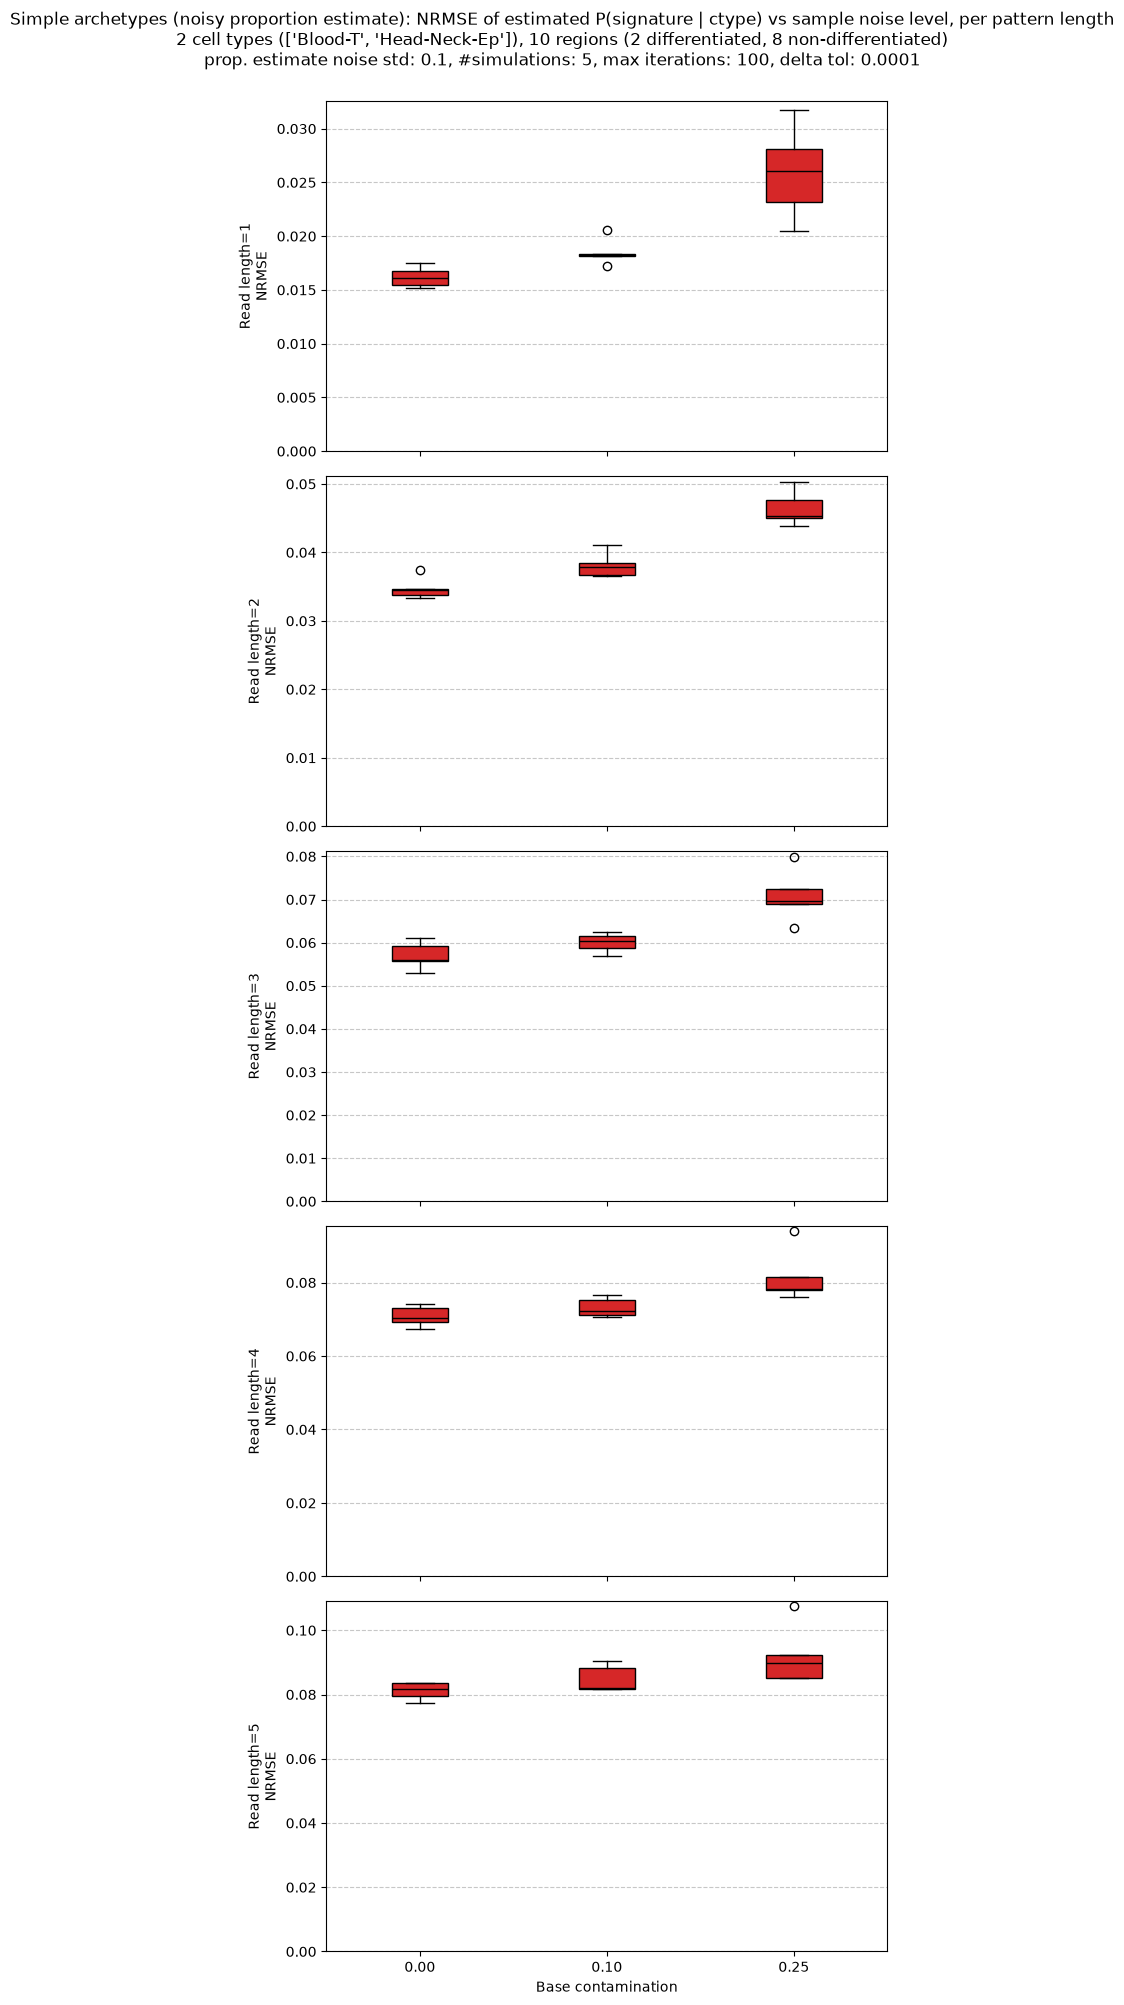

In [20]:
# Plot the NRMSE of P(sig | ctype) for Experiment 2.
fig, axes = plt.subplots(
    5,
    1,
    figsize=(1.6 * len(noise_grid) + 2, 4 * 5),
    sharex=True,
    squeeze=False,
)

for row_idx, read_length in enumerate(range(1, 6)):
    ax = axes[row_idx, 0]
    data_to_plot = [
        results_exp2_sig_given_ctype[noise_level][read_length]
        for noise_level in noise_grid
    ]
    bp = ax.boxplot(
        data_to_plot,
        positions=range(len(noise_grid)),
        patch_artist=True,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("tab:red")
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_ylim(0, None)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylabel(f"Read length={read_length}\nNRMSE")
    ax.set_xticks(range(len(noise_grid)))
    ax.set_xticklabels([f"{noise_level:.2f}" for noise_level in noise_grid])
axes[-1, 0].set_xlabel("Base contamination")

fig.suptitle(
    "Simple archetypes (noisy proportion estimate): NRMSE of estimated "
    "P(signature | ctype) vs sample noise level, per pattern length"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nprop. estimate noise std: {PROP_ESTIMATE_NOISE_STD}, #simulations: {N_SIMULATIONS}, "
    f"max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}",
    y=1.0,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_noisy_proportions_nrmse_"
        f"nctypes={N_CTYPES}_ndiff={N_DIFFERENTIATED_REGIONS}_nnondiff={N_NON_DIFFERENTIATED_REGIONS}_"
        f"noisy-samples={N_NOISY_SAMPLES}_sample-size={SAMPLE_SIZE}_"
        f"max-iterations={MAX_NUM_ITERATIONS}_delta-tol={DELTA_TOL}_"
        f"prop-estimate-noise-std={PROP_ESTIMATE_NOISE_STD}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()

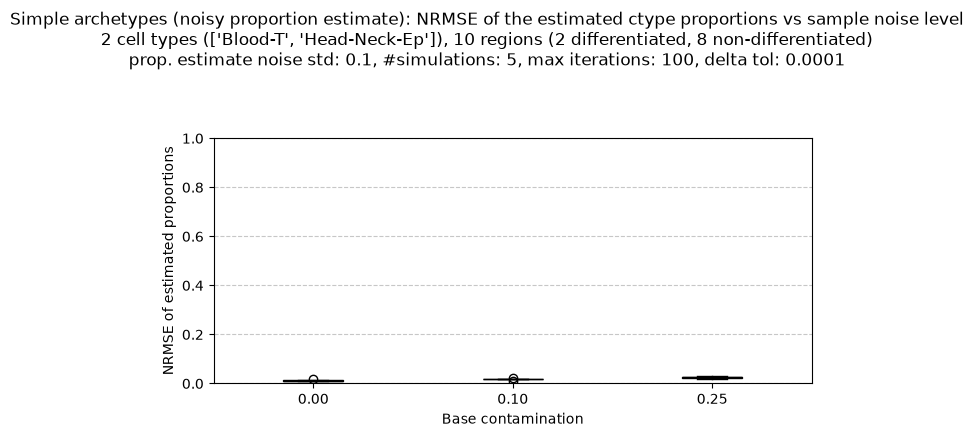

In [21]:
# Plot the NRMSE of the estimated proportions for Experiment 2.
fig, ax = plt.subplots(figsize=(1.6 * len(noise_grid) + 2, 4))

data_to_plot = [results_exp2_proportions[noise_level] for noise_level in noise_grid]
bp = ax.boxplot(
    data_to_plot,
    positions=range(len(noise_grid)),
    patch_artist=True,
)
for patch in bp["boxes"]:
    patch.set_facecolor("tab:red")
for median in bp["medians"]:
    median.set_color("black")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_ylabel("NRMSE of estimated proportions")
ax.set_xlabel("Base contamination")
ax.set_xticks(range(len(noise_grid)))
ax.set_xticklabels([f"{noise_level:.2f}" for noise_level in noise_grid])

fig.suptitle(
    "Simple archetypes (noisy proportion estimate): NRMSE of the estimated ctype "
    "proportions vs sample noise level"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nprop. estimate noise std: {PROP_ESTIMATE_NOISE_STD}, #simulations: {N_SIMULATIONS}, "
    f"max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}",
    y=1.08,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_noisy_proportions_ctype_prop_nrmse_"
        f"nctypes={N_CTYPES}_ndiff={N_DIFFERENTIATED_REGIONS}_nnondiff={N_NON_DIFFERENTIATED_REGIONS}_"
        f"noisy-samples={N_NOISY_SAMPLES}_sample-size={SAMPLE_SIZE}_"
        f"max-iterations={MAX_NUM_ITERATIONS}_delta-tol={DELTA_TOL}_"
        f"prop-estimate-noise-std={PROP_ESTIMATE_NOISE_STD}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()

## Experiment 3: varying the noise on the proportion estimate



Here we keep the **base contamination** of the samples fixed and instead vary the
standard deviation `PROP_ESTIMATE_NOISE_STD` of the Gaussian noise added to the
true proportions before they are passed to the method (which still re-estimates
them with `reestimate_ctype_proba_per_sample=True`). This probes how robust the
re-estimation is to the quality of the initial proportion estimate.

As in Experiment 2 we plot two quantities, but now as a function of the
proportion-estimate noise level:

- the NRMSE between the estimated $P(\mathrm{sig}\mid\mathrm{ctype})$ and the
  ground truth (pooled over regions), and
- the NRMSE between the proportions estimated by the method and the true mixing
  proportions of the samples.


In [ ]:
# Fixed base contamination of the samples for this experiment.
FIXED_BASE_CONTAMINATION = 0.15
std_noise_on_noise = 0.1
DOMINANT_CTYPE_FIXED = (
    0  # fix the dominant cell type to the first one for this experiment
)

# Grid of standard deviations of the noise added to the true proportions.
prop_estimate_noise_std_grid = np.array([0.0, 0.05, 0.1, 0.2, 0.4, 0.6])

N_SIMULATIONS = 20
N_NOISY_SAMPLES = 10
MAX_NUM_ITERATIONS = 100
DELTA_TOL = 1e-4
SAMPLE_SIZE = 800
min_count_threshold_per_ctype_for_nrmse = 5

In [ ]:
rng = np.random.default_rng(1)

# Store raw predictions, estimated proportions and true proportions per simulation.
results_exp3_predictions = {std_val: [] for std_val in prop_estimate_noise_std_grid}
results_exp3_estimated_props = {std_val: [] for std_val in prop_estimate_noise_std_grid}
results_exp3_true_props = {std_val: [] for std_val in prop_estimate_noise_std_grid}

n_loops = len(prop_estimate_noise_std_grid) * N_SIMULATIONS
with tqdm(total=n_loops, desc="Exp 3: vary prop. estimate noise") as pbar:
    for prop_noise_std in prop_estimate_noise_std_grid:
        for sim_id in range(N_SIMULATIONS):
            ctype_prop_per_sample = build_ctype_prop_per_sample(
                FIXED_BASE_CONTAMINATION,
                std_noise_on_noise,
                N_NOISY_SAMPLES,
                N_CTYPES,
                dominant_ctype_fixed=DOMINANT_CTYPE_FIXED,
            )
            sample_sizes = np.full(N_NOISY_SAMPLES, SAMPLE_SIZE, dtype=int)
            counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
                og_dataset,
                selected_ctypes,
                ctype_prop_per_sample,
                sample_sizes,
                signature_positions,
                N_CTYPES,
            )

            # noisy estimate of the proportions given to the method
            noisy_prop_estimate = perturb_proportions(
                ctype_prop_per_sample, prop_noise_std, rng
            )
            results_exp3_true_props[prop_noise_std].append(ctype_prop_per_sample.copy())

            estimated_sig_given_ctype, estimated_props = (
                sl_with_simple_archetypes_with_multiple_regions(
                    counts_sig_per_sample,
                    noisy_prop_estimate,
                    reestimate_ctype_proba_per_sample=True,
                    max_num_iterations=MAX_NUM_ITERATIONS,
                    delta_tol=DELTA_TOL,
                )
            )
            results_exp3_predictions[prop_noise_std].append(estimated_sig_given_ctype)
            results_exp3_estimated_props[prop_noise_std].append(estimated_props)
            pbar.update(1)

In [ ]:
# Compute NRMSE metrics from the stored raw outputs.
results_exp3_sig_given_ctype = {
    std_val: {read_length: [] for read_length in range(1, 6)}
    for std_val in prop_estimate_noise_std_grid
}
results_exp3_proportions = {std_val: [] for std_val in prop_estimate_noise_std_grid}

ref_counts_for_nrmse = og_counts_sig_per_ctype
for std_val in prop_estimate_noise_std_grid:
    for sim_id, estimated_sig_given_ctype in enumerate(
        results_exp3_predictions[std_val]
    ):
        nrmse_per_length = compute_nrmse_per_sig_length_multi_region(
            estimated_sig_given_ctype,
            pgt_naive_sl_sig_given_ctype,
            ref_counts_for_nrmse,
            min_count_threshold_per_ctype_for_nrmse,
        )
        for read_length in range(1, 6):
            if read_length in nrmse_per_length:
                results_exp3_sig_given_ctype[std_val][read_length].append(
                    nrmse_per_length[read_length]
                )

        estimated_props = results_exp3_estimated_props[std_val][sim_id]
        true_props = results_exp3_true_props[std_val][sim_id]
        results_exp3_proportions[std_val].append(nrmse(true_props, estimated_props))

In [ ]:
# Plot the NRMSE of P(sig | ctype) for Experiment 3.
fig, axes = plt.subplots(
    5,
    1,
    figsize=(1.6 * len(prop_estimate_noise_std_grid) + 2, 4 * 5),
    sharex=True,
    squeeze=False,
)

for row_idx, read_length in enumerate(range(1, 6)):
    ax = axes[row_idx, 0]
    data_to_plot = [
        results_exp3_sig_given_ctype[std_val][read_length]
        for std_val in prop_estimate_noise_std_grid
    ]
    bp = ax.boxplot(
        data_to_plot,
        positions=range(len(prop_estimate_noise_std_grid)),
        patch_artist=True,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("tab:red")
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_ylim(0, None)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylabel(f"Read length={read_length}\nNRMSE")
    ax.set_xticks(range(len(prop_estimate_noise_std_grid)))
    ax.set_xticklabels([f"{std_val:.2f}" for std_val in prop_estimate_noise_std_grid])
axes[-1, 0].set_xlabel("Proportion estimate noise std")

fig.suptitle(
    "Simple archetypes: NRMSE of estimated P(signature | ctype) "
    "vs proportion-estimate noise, per pattern length"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nbase contamination: {FIXED_BASE_CONTAMINATION}, #simulations: {N_SIMULATIONS}, "
    f"max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}, dominant ctype: {DOMINANT_CTYPE_FIXED}",
    y=1.0,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_vary_prop_noise_nrmse_"
        f"nctypes={N_CTYPES}_ndiff={N_DIFFERENTIATED_REGIONS}_nnondiff={N_NON_DIFFERENTIATED_REGIONS}_"
        f"noisy-samples={N_NOISY_SAMPLES}_sample-size={SAMPLE_SIZE}_"
        f"max-iterations={MAX_NUM_ITERATIONS}_delta-tol={DELTA_TOL}_"
        f"base-contamination={FIXED_BASE_CONTAMINATION}_dominant-ctype={DOMINANT_CTYPE_FIXED}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()

In [ ]:
# Plot the NRMSE of the estimated proportions for Experiment 3.
fig, ax = plt.subplots(figsize=(1.6 * len(prop_estimate_noise_std_grid) + 2, 4))

data_to_plot = [
    results_exp3_proportions[std_val] for std_val in prop_estimate_noise_std_grid
]
bp = ax.boxplot(
    data_to_plot,
    positions=range(len(prop_estimate_noise_std_grid)),
    patch_artist=True,
)
for patch in bp["boxes"]:
    patch.set_facecolor("tab:red")
for median in bp["medians"]:
    median.set_color("black")
ax.set_ylim(0, None)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_ylabel("NRMSE of estimated proportions")
ax.set_xlabel("Proportion estimate noise std")
ax.set_xticks(range(len(prop_estimate_noise_std_grid)))
ax.set_xticklabels([f"{std_val:.2f}" for std_val in prop_estimate_noise_std_grid])

fig.suptitle(
    "Simple archetypes: NRMSE of the estimated ctype proportions "
    "vs proportion-estimate noise"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nbase contamination: {FIXED_BASE_CONTAMINATION}, #simulations: {N_SIMULATIONS}, "
    f"max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}, dominant ctype: {DOMINANT_CTYPE_FIXED}",
    y=1.08,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_vary_prop_noise_ctype_prop_nrmse_"
        f"nctypes={N_CTYPES}_ndiff={N_DIFFERENTIATED_REGIONS}_nnondiff={N_NON_DIFFERENTIATED_REGIONS}_"
        f"noisy-samples={N_NOISY_SAMPLES}_sample-size={SAMPLE_SIZE}_"
        f"max-iterations={MAX_NUM_ITERATIONS}_delta-tol={DELTA_TOL}_"
        f"base-contamination={FIXED_BASE_CONTAMINATION}_dominant-ctype={DOMINANT_CTYPE_FIXED}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()

## Experiment 4: varying the coverage and the number of samples

The two previous experiments probe the robustness of the method to the *quality*
of its inputs (contamination of the samples, noise on the proportion estimate).
Here we instead probe how it benefits from the *quantity* of data, along the two
axes that a real study can actually buy:

- the **number of noisy samples** jointly deconvolved (more samples means more
  independent mixtures constraining the same shared archetypes), and
- the **coverage**, i.e. how many reads cover each CpG of each sample (more reads
  means less sampling noise on each sample's signature counts).

The knob we turn is the number of reads drawn per sample per region, but the
quantity **reported on the plots is the realized coverage**: the average number of
read calls per CpG per sample, measured on the signature counts actually handed to
the method. The two are not interchangeable — a drawn read is only seen by the
method if it exactly matches one of the region's `(start, read_length)` signature
positions, and it then covers `read_length` of the region's CpG positions — so the
realized coverage is what the method is really given.

Everything else is kept fixed: the base contamination of the samples, the noise
added to the proportion estimate handed to the method, and the set of regions and
cell types. As in Experiments 2 and 3 the method receives a noisy estimate of the
proportions and re-estimates them (`reestimate_ctype_proba_per_sample=True`), so
both reported quantities are relevant:

- the NRMSE between the estimated $P(\mathrm{sig}\mid\mathrm{ctype})$ and the
  ground truth (pooled over regions), and
- the NRMSE between the estimated and the true mixing proportions.

`DOMINANT_CTYPE_FIXED` selects the composition of the panel of samples:

- `None` (the default) **cycles** the dominant cell type over the samples, as in
  Experiments 1 and 2, so each cell type dominates in a fair share of them;
- an integer **pins** it, as in Experiment 3, so one cell type dominates every
  sample and the others are only ever observed as contamination.

The choice bites hardest on the number-of-samples axis: with a pinned dominant
cell type the extra samples all repeat the same composition, so they mostly buy
depth on one archetype instead of constraints on the others. Running the grid both
ways is the point — it separates "more samples" from "more *different* samples".

In [22]:
# Sample composition, held fixed across the whole grid.
FIXED_BASE_CONTAMINATION = 0.15
std_noise_on_noise = 0.1
PROP_ESTIMATE_NOISE_STD = 0.1

# Which cell type dominates each sample. None cycles the dominant cell type over
# the samples (as in Experiments 1 and 2); an integer pins it to that cell type in
# every sample (as in Experiment 3), leaving the other cell types visible only as
# contamination.
DOMINANT_CTYPE_FIXED = None

# The two axes of the experiment.
n_samples_grid = np.array([2, 4, 8, 16])  # number of jointly deconvolved samples
sample_size_grid = np.array([50, 100, 200, 400, 800])  # reads / sample / region

N_SIMULATIONS = 10
MAX_NUM_ITERATIONS = 100
DELTA_TOL = 1e-4
MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE = 5
min_count_threshold_per_ctype_for_nrmse = 5

if DOMINANT_CTYPE_FIXED is None:
    # When the dominant cell type cycles, every cell type must dominate in at
    # least one sample; otherwise the smallest grid points silently degenerate
    # into the pinned setting and the two are no longer comparable.
    assert n_samples_grid.min() >= N_CTYPES, (
        "With a cycling dominant cell type, the smallest number of samples must "
        "be at least N_CTYPES so that every cell type dominates in at least one "
        "sample."
    )
    DOMINANT_CTYPE_LABEL = "cycling"
else:
    assert (
        0 <= DOMINANT_CTYPE_FIXED < N_CTYPES
    ), "DOMINANT_CTYPE_FIXED must be a valid cell-type index (or None)."
    DOMINANT_CTYPE_LABEL = f"pinned to {selected_ctypes[DOMINANT_CTYPE_FIXED]}"

print(
    f"{len(n_samples_grid) * len(sample_size_grid)} grid points "
    f"x {N_SIMULATIONS} simulations = "
    f"{len(n_samples_grid) * len(sample_size_grid) * N_SIMULATIONS} runs"
    f"\ndominant cell type: {DOMINANT_CTYPE_LABEL}"
)

20 grid points x 10 simulations = 200 runs


In [23]:
# The method sees, per region, the CpG span running from the first signature start
# to the end of the longest signature, and only the reads that exactly match one of
# the (start, read_length) signature positions. The coverage reported on the plots
# is therefore measured on the counts actually handed to the method rather than
# derived from the number of drawn reads.


def compute_cpg_span_per_region(sig_positions_per_region):
    """Number of CpG positions spanned by the signatures of each region.

    Matches the span ``sl_with_simple_archetypes_with_multiple_regions`` uses for
    its archetypes: from the first signature start to the end (exclusive) of the
    signature reaching furthest right.
    """
    return {
        region_id: max(
            start + read_length
            for start, read_lengths in sig_positions.items()
            for read_length in read_lengths
        )
        - min(sig_positions.keys())
        for region_id, sig_positions in sig_positions_per_region.items()
    }


def compute_coverage_per_cpg(counts_sig_per_sample, cpg_span_per_region):
    """Realized coverage per region: read calls per CpG for a single sample.

    A signature of length ``L`` observed once contributes ``L`` calls, spread over
    the ``L`` CpG positions it covers. The total is averaged over the samples (so
    the result is the coverage *of one sample*, independent of how many samples the
    experiment uses) and divided by the region's CpG span.

    Args:
        counts_sig_per_sample: ``{region: {start: {read_length: array of shape
            (n_samples, 2**read_length)}}}``, as handed to the method.
        cpg_span_per_region: ``{region: number of CpG positions}``.

    Returns:
        ``{region: average number of read calls per CpG per sample}``.
    """
    coverage_per_region = {}
    for region_id, region_counts in counts_sig_per_sample.items():
        n_calls_per_sample = 0.0  # becomes an (n_samples,) array on first addition
        for start, read_lengths in region_counts.items():
            for read_length, counts in read_lengths.items():
                n_calls_per_sample = (
                    n_calls_per_sample + counts.sum(axis=1) * read_length
                )
        coverage_per_region[region_id] = (
            float(np.mean(n_calls_per_sample)) / cpg_span_per_region[region_id]
        )
    return coverage_per_region


cpg_span_per_region = compute_cpg_span_per_region(signature_positions)
print(
    "CpG span per region: "
    f"{ {region_id: cpg_span_per_region[region_id] for region_id in sorted(cpg_span_per_region)} }"
)

CpG span per region: {0: 11, 1: 12, 2: 20, 3: 9, 4: 17, 5: 12, 6: 12, 7: 17, 8: 13, 9: 11}


In [24]:
rng = np.random.default_rng(2)

# Contrarily to the previous experiments, the raw predictions are NOT stored and
# the NRMSE is computed inside the loop: the grid has
# len(n_samples_grid) * len(sample_size_grid) * N_SIMULATIONS runs, and a single
# prediction holds one (n_ctypes, 2**read_length) array per (region, start,
# read_length), which does not fit comfortably in memory over the whole grid.
ref_counts_for_nrmse = og_counts_sig_per_ctype

# All three dicts are keyed by the grid point (n_samples, sample_size).
results_exp4_sig_given_ctype = {}
results_exp4_proportions = {}
results_exp4_coverage = {}  # realized coverage per CpG per sample, per region

n_loops = len(n_samples_grid) * len(sample_size_grid) * N_SIMULATIONS
with tqdm(total=n_loops, desc="Exp 4: vary #samples and coverage") as pbar:
    for n_samples in n_samples_grid:
        for sample_size in sample_size_grid:
            grid_point = (int(n_samples), int(sample_size))
            results_exp4_sig_given_ctype[grid_point] = {
                read_length: []
                for read_length in range(
                    1, MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE + 1
                )
            }
            results_exp4_proportions[grid_point] = []
            results_exp4_coverage[grid_point] = []

            for sim_id in range(N_SIMULATIONS):
                ctype_prop_per_sample = build_ctype_prop_per_sample(
                    FIXED_BASE_CONTAMINATION,
                    std_noise_on_noise,
                    int(n_samples),
                    N_CTYPES,
                    dominant_ctype_fixed=DOMINANT_CTYPE_FIXED,
                )
                sample_sizes = np.full(int(n_samples), int(sample_size), dtype=int)
                counts_sig_per_sample = generate_noisy_samples_counts_multi_region(
                    og_dataset,
                    selected_ctypes,
                    ctype_prop_per_sample,
                    sample_sizes,
                    signature_positions,
                    N_CTYPES,
                )

                # realized coverage of the counts the method is about to receive
                results_exp4_coverage[grid_point].append(
                    compute_coverage_per_cpg(counts_sig_per_sample, cpg_span_per_region)
                )

                # noisy estimate of the proportions given to the method
                noisy_prop_estimate = perturb_proportions(
                    ctype_prop_per_sample, PROP_ESTIMATE_NOISE_STD, rng
                )

                estimated_sig_given_ctype, estimated_props = (
                    sl_with_simple_archetypes_with_multiple_regions(
                        counts_sig_per_sample,
                        noisy_prop_estimate,
                        reestimate_ctype_proba_per_sample=True,
                        max_num_iterations=MAX_NUM_ITERATIONS,
                        delta_tol=DELTA_TOL,
                    )
                )

                nrmse_per_length = compute_nrmse_per_sig_length_multi_region(
                    estimated_sig_given_ctype,
                    pgt_naive_sl_sig_given_ctype,
                    ref_counts_for_nrmse,
                    min_count_threshold_per_ctype_for_nrmse,
                )
                for read_length in range(
                    1, MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE + 1
                ):
                    if read_length in nrmse_per_length:
                        results_exp4_sig_given_ctype[grid_point][read_length].append(
                            nrmse_per_length[read_length]
                        )
                results_exp4_proportions[grid_point].append(
                    nrmse(ctype_prop_per_sample, estimated_props)
                )
                pbar.update(1)

Exp 4: vary #samples and coverage: 100%|██████████| 200/200 [08:41<00:00,  2.61s/it]


In [25]:
# Realized coverage of every run, as a long table.
coverage_records = [
    {
        "n_samples": n_samples,
        "sample_size": sample_size,
        "sim_id": sim_id,
        "region_id": region_id,
        "coverage": coverage,
    }
    for (n_samples, sample_size), coverage_dicts in results_exp4_coverage.items()
    for sim_id, coverage_per_region in enumerate(coverage_dicts)
    for region_id, coverage in coverage_per_region.items()
]
df_coverage_exp4 = pd.DataFrame(coverage_records)

# The coverage of a single sample does not depend on how many samples there are,
# so the grid points sharing a sample size are pooled. This is the x-axis of every
# plot below (one value per entry of sample_size_grid, in the same order).
coverage_per_cpg_grid = np.array(
    [
        df_coverage_exp4.loc[
            df_coverage_exp4["sample_size"] == int(sample_size), "coverage"
        ].mean()
        for sample_size in sample_size_grid
    ]
)

# Sanity check on the pooling: the spread across the numbers of samples should be
# negligible compared to the spacing of the grid.
spread_across_n_samples = df_coverage_exp4.groupby(["sample_size", "n_samples"])[
    "coverage"
].mean().groupby("sample_size").agg(lambda x: x.max() - x.min())
print("Mean realized coverage per CpG per sample (averaged over regions):")
for sample_size, coverage in zip(sample_size_grid, coverage_per_cpg_grid):
    print(
        f"  {int(sample_size):>4d} reads/sample/region -> {coverage:6.2f}x "
        f"(spread across #samples: {spread_across_n_samples[int(sample_size)]:.3f})"
    )

# Per-region breakdown: the regions do not all have the same span nor the same
# read-length distribution, so their realized coverage differs.
df_coverage_exp4.pivot_table(
    index="sample_size", columns="region_id", values="coverage", aggfunc="mean"
).round(2)

Mean realized coverage per CpG per sample (averaged over regions):
    50 reads/sample/region ->   9.19x (spread across #samples: 0.126)
   100 reads/sample/region ->  18.39x (spread across #samples: 0.129)
   200 reads/sample/region ->  36.72x (spread across #samples: 0.155)
   400 reads/sample/region ->  73.49x (spread across #samples: 0.343)
   800 reads/sample/region -> 147.02x (spread across #samples: 0.293)


region_id,0,1,2,3,4,5,6,7,8,9
sample_size,,,,,,,,,,
50,8.53,10.04,7.65,8.12,7.36,15.95,7.05,7.58,9.54,10.08
100,17.24,19.92,15.35,16.15,14.76,32.14,13.96,15.25,18.92,20.18
200,34.26,40.03,30.73,32.31,29.32,64.28,28.02,30.19,37.77,40.30
400,68.73,80.08,61.63,64.69,58.71,127.96,56.14,60.54,75.38,81.03
800,137.28,159.53,123.26,129.33,117.35,257.20,112.67,121.18,151.20,161.22


In [26]:
def median_and_iqr(values):
    """Median and inter-quartile range of a list of values (NaN if empty)."""
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    return (
        float(np.median(values)),
        float(np.percentile(values, 25)),
        float(np.percentile(values, 75)),
    )


def plot_trend_vs_coverage(ax, values_per_grid_point, colors):
    """Plot the median NRMSE vs realized coverage, one line per number of samples.

    ``values_per_grid_point`` maps ``(n_samples, sample_size)`` to the list of
    per-simulation values; the inter-quartile range is shaded around each line. The
    x positions are the realized coverages (``coverage_per_cpg_grid``), and each
    tick also recalls the number of drawn reads that produced it.
    """
    for color, n_samples in zip(colors, n_samples_grid):
        medians, lows, highs = [], [], []
        for sample_size in sample_size_grid:
            median, low, high = median_and_iqr(
                values_per_grid_point[(int(n_samples), int(sample_size))]
            )
            medians.append(median)
            lows.append(low)
            highs.append(high)
        ax.plot(
            coverage_per_cpg_grid,
            medians,
            marker="o",
            color=color,
            label=f"{int(n_samples)} samples",
        )
        ax.fill_between(coverage_per_cpg_grid, lows, highs, color=color, alpha=0.15)
    ax.set_xscale("log")
    ax.set_xticks(coverage_per_cpg_grid)
    ax.set_xticklabels(coverage_tick_labels)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_ylim(0, None)
    ax.grid(linestyle="--", alpha=0.7)


colors_per_n_samples = plt.cm.viridis(np.linspace(0.0, 0.85, len(n_samples_grid)))

# Tick labels: realized coverage, with the number of drawn reads per sample per
# region that produced it on a second line.
coverage_tick_labels = [
    f"{coverage:.1f}x\n({int(sample_size)} reads)"
    for coverage, sample_size in zip(coverage_per_cpg_grid, sample_size_grid)
]
COVERAGE_AXIS_LABEL = "Realized coverage (read calls per CpG per sample)"

# Shared stem of the figure file names. The grids are compacted (and the labels
# shortened) because the full parameter list overran the 255-byte file-name limit.
EXP4_FILENAME_STEM = (
    f"nctypes={N_CTYPES}_ndiff={N_DIFFERENTIATED_REGIONS}"
    f"_nnondiff={N_NON_DIFFERENTIATED_REGIONS}"
    f"_nsamples={'-'.join(str(int(n)) for n in n_samples_grid)}"
    f"_reads={'-'.join(str(int(s)) for s in sample_size_grid)}"
    f"_nsim={N_SIMULATIONS}_maxit={MAX_NUM_ITERATIONS}_tol={DELTA_TOL}"
    f"_contamination={FIXED_BASE_CONTAMINATION}_prop-noise={PROP_ESTIMATE_NOISE_STD}"
    f"_dominant-ctype={DOMINANT_CTYPE_FIXED}"
)

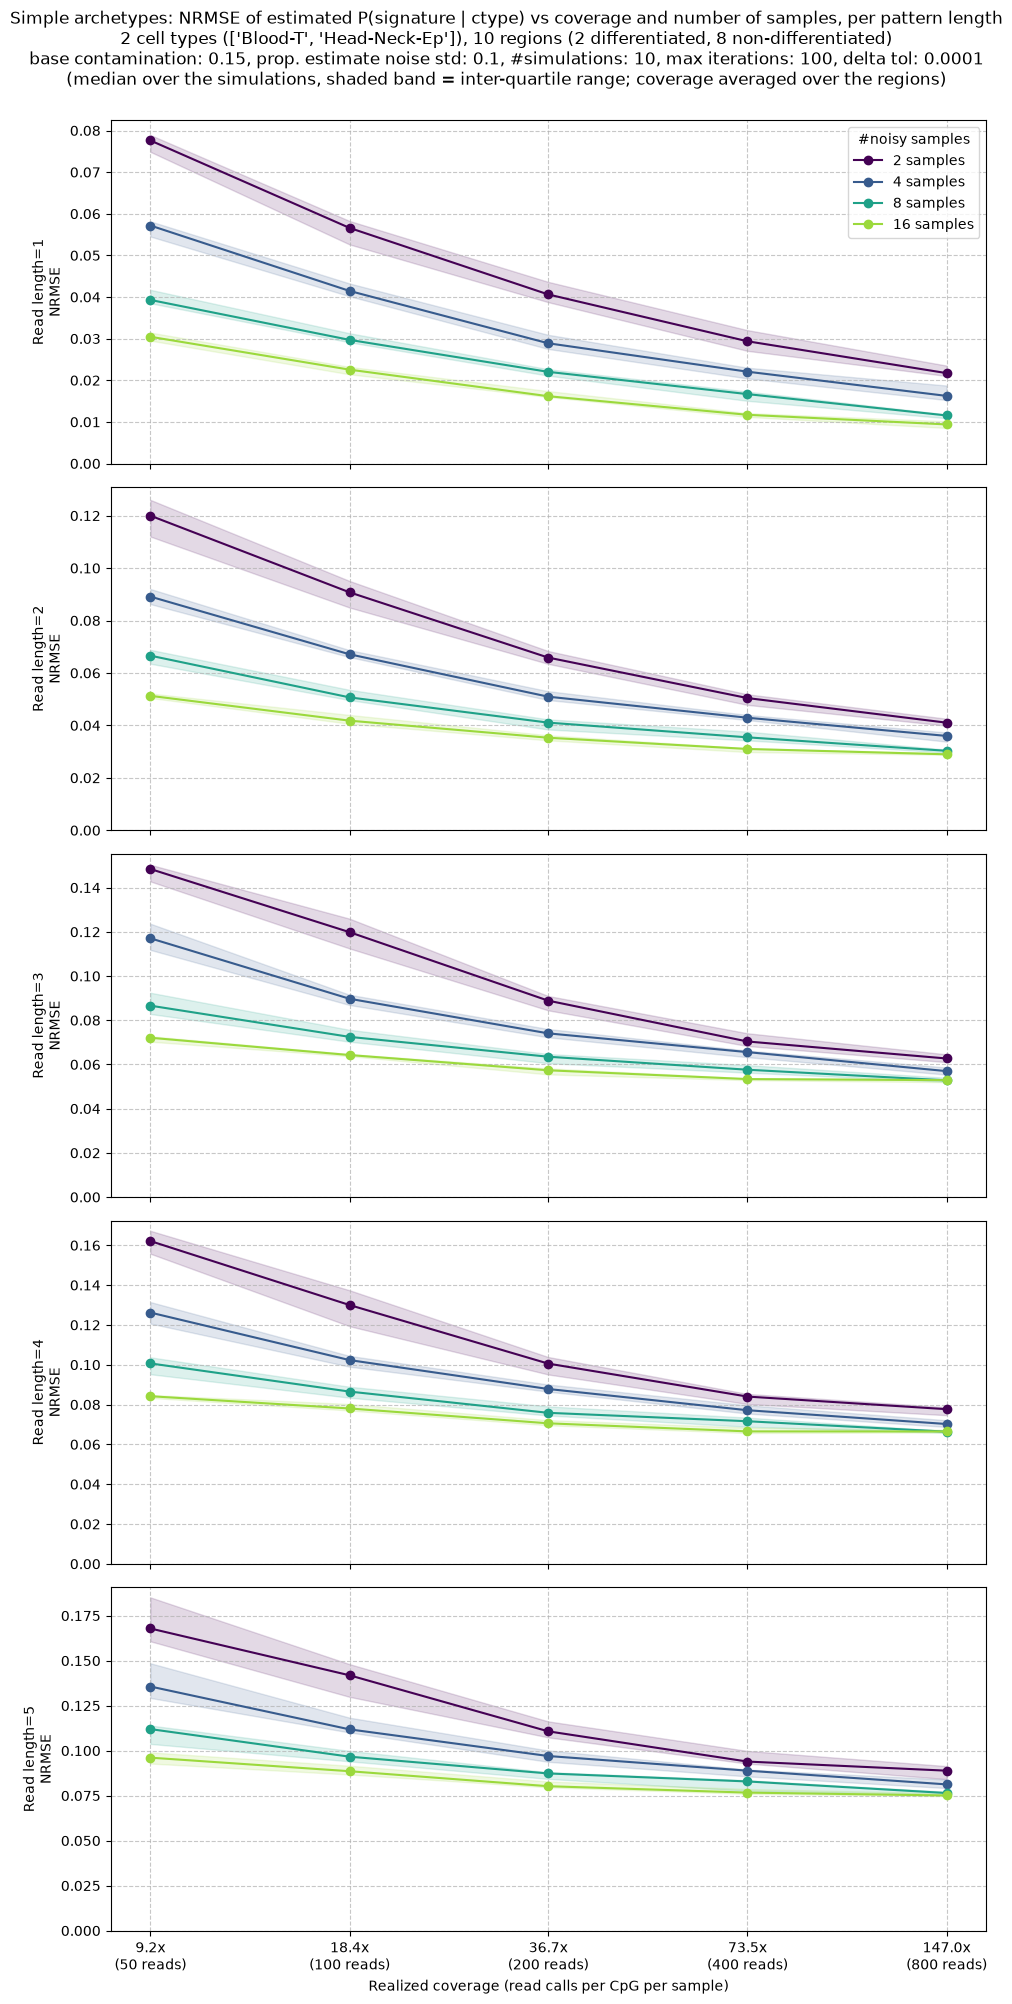

In [27]:
# Plot the NRMSE of P(sig | ctype) for Experiment 4, per pattern length.
fig, axes = plt.subplots(
    MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE,
    1,
    figsize=(
        1.6 * len(sample_size_grid) + 2,
        4 * MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE,
    ),
    sharex=True,
    squeeze=False,
)

for row_idx, read_length in enumerate(
    range(1, MAX_PATTERN_LENGTH_TO_CONSIDER_FOR_NRMSE + 1)
):
    ax = axes[row_idx, 0]
    plot_trend_vs_coverage(
        ax,
        {
            grid_point: values[read_length]
            for grid_point, values in results_exp4_sig_given_ctype.items()
        },
        colors_per_n_samples,
    )
    ax.set_ylabel(f"Read length={read_length}\nNRMSE")
axes[0, 0].legend(title="#noisy samples")
axes[-1, 0].set_xlabel(COVERAGE_AXIS_LABEL)

fig.suptitle(
    "Simple archetypes: NRMSE of estimated P(signature | ctype) vs coverage and "
    "number of samples, per pattern length"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nbase contamination: {FIXED_BASE_CONTAMINATION}, prop. estimate noise std: "
    f"{PROP_ESTIMATE_NOISE_STD}, #simulations: {N_SIMULATIONS}, "
    f"max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}, "
    f"dominant ctype: {DOMINANT_CTYPE_LABEL}"
    "\n(median over the simulations, shaded band = inter-quartile range; coverage "
    "averaged over the regions)",
    y=1.0,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_vary_nsamples_coverage_nrmse_{EXP4_FILENAME_STEM}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()


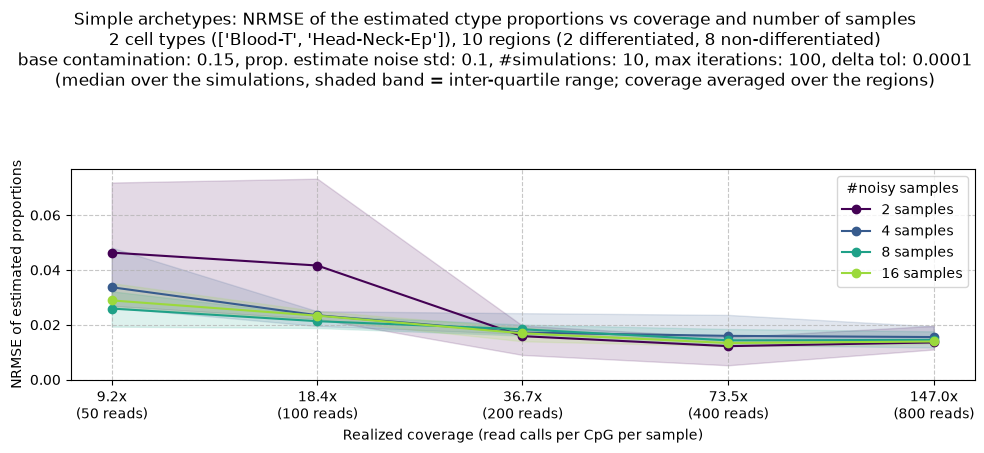

In [28]:
# Plot the NRMSE of the estimated proportions for Experiment 4.
fig, ax = plt.subplots(figsize=(1.6 * len(sample_size_grid) + 2, 4))

plot_trend_vs_coverage(ax, results_exp4_proportions, colors_per_n_samples)
ax.set_ylabel("NRMSE of estimated proportions")
ax.set_xlabel(COVERAGE_AXIS_LABEL)
ax.legend(title="#noisy samples")

fig.suptitle(
    "Simple archetypes: NRMSE of the estimated ctype proportions vs coverage and "
    "number of samples"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nbase contamination: {FIXED_BASE_CONTAMINATION}, prop. estimate noise std: "
    f"{PROP_ESTIMATE_NOISE_STD}, #simulations: {N_SIMULATIONS}, "
    f"max iterations: {MAX_NUM_ITERATIONS}, delta tol: {DELTA_TOL}, "
    f"dominant ctype: {DOMINANT_CTYPE_LABEL}"
    "\n(median over the simulations, shaded band = inter-quartile range; coverage "
    "averaged over the regions)",
    y=1.12,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_vary_nsamples_coverage_ctype_prop_nrmse_"
        f"{EXP4_FILENAME_STEM}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()


The line plots above read one axis at a time. The heatmaps below show the whole
`(number of samples, coverage)` grid at once, which makes the trade-off between
the two directly visible: whether a given NRMSE is more cheaply reached by adding
samples or by adding reads per sample.

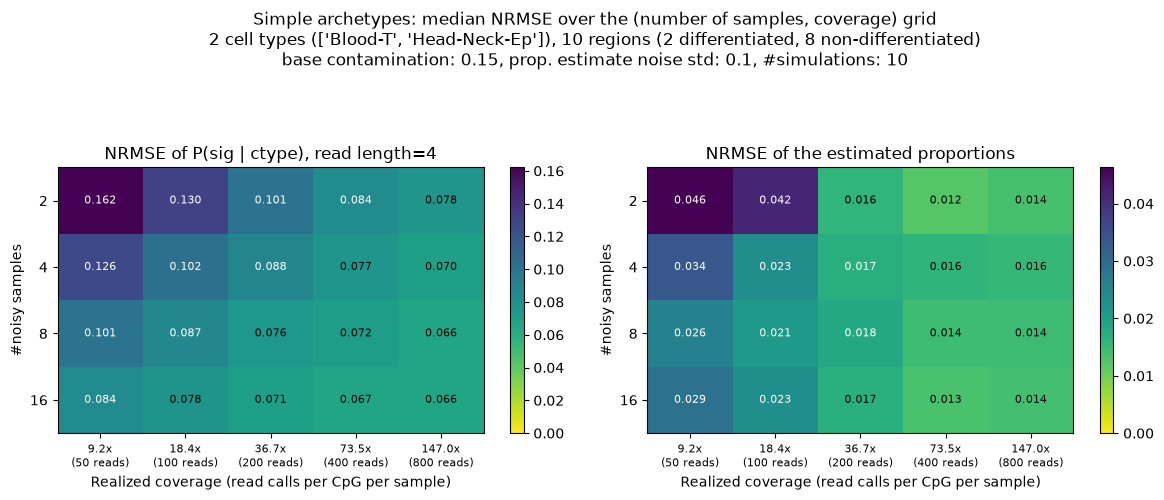

In [30]:
# Read length shown in the left panel (the right panel is the proportion NRMSE,
# which has no read-length dimension).
HEATMAP_READ_LENGTH = 4

heatmap_sig = np.array(
    [
        [
            median_and_iqr(
                results_exp4_sig_given_ctype[(int(n_samples), int(sample_size))][
                    HEATMAP_READ_LENGTH
                ]
            )[0]
            for sample_size in sample_size_grid
        ]
        for n_samples in n_samples_grid
    ]
)
heatmap_props = np.array(
    [
        [
            median_and_iqr(
                results_exp4_proportions[(int(n_samples), int(sample_size))]
            )[0]
            for sample_size in sample_size_grid
        ]
        for n_samples in n_samples_grid
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(6 + 1.2 * len(sample_size_grid), 4.5))
panels = [
    (heatmap_sig, f"NRMSE of P(sig | ctype), read length={HEATMAP_READ_LENGTH}"),
    (heatmap_props, "NRMSE of the estimated proportions"),
]
for ax, (matrix, title) in zip(axes, panels):
    im = ax.imshow(matrix, cmap="viridis_r", aspect="auto", vmin=0)
    ax.set_xticks(range(len(sample_size_grid)))
    ax.set_xticklabels(coverage_tick_labels, fontsize=8)
    ax.set_yticks(range(len(n_samples_grid)))
    ax.set_yticklabels([str(int(n)) for n in n_samples_grid])
    ax.set_xlabel(COVERAGE_AXIS_LABEL)
    ax.set_ylabel("#noisy samples")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if np.isnan(matrix[i, j]):
                continue
            ax.text(
                j,
                i,
                f"{matrix[i, j]:.3f}",
                ha="center",
                va="center",
                color="white" if matrix[i, j] > np.nanmedian(matrix) else "black",
                fontsize=8,
            )
    fig.colorbar(im, ax=ax)

fig.suptitle(
    "Simple archetypes: median NRMSE over the (number of samples, coverage) grid"
    f"\n{N_CTYPES} cell types ({selected_ctypes}), {N_REGIONS} regions "
    f"({N_DIFFERENTIATED_REGIONS} differentiated, {N_NON_DIFFERENTIATED_REGIONS} non-differentiated)"
    f"\nbase contamination: {FIXED_BASE_CONTAMINATION}, prop. estimate noise std: "
    f"{PROP_ESTIMATE_NOISE_STD}, #simulations: {N_SIMULATIONS}, "
    f"dominant ctype: {DOMINANT_CTYPE_LABEL}",
    y=1.10,
)
plt.tight_layout()
plt.savefig(
    Path(
        f"./output/several_regions_vary_nsamples_coverage_heatmap_"
        f"{EXP4_FILENAME_STEM}_read-length={HEATMAP_READ_LENGTH}.pdf"
    ),
    bbox_inches="tight",
)
plt.show()
